In [1]:
import numpy as np
import pandas as pd
import pyxdf
import mne

In [2]:
data, header = pyxdf.load_xdf("../lab_recorder_data/sub-scott_sham1_ses-scott_sham1_task-Default_run-001_eeg.xdf")
data

[{'info': defaultdict(list,
              {'name': ['PsychoPyMarkers'],
               'type': ['Markers'],
               'channel_count': ['1'],
               'channel_format': ['string'],
               'source_id': ['-4379379051682882619'],
               'nominal_srate': ['0.000000000000000'],
               'version': ['1.100000000000000'],
               'created_at': ['2126654.882835100'],
               'uid': ['443a876e-6c81-4320-b1c4-53fc740472e4'],
               'session_id': ['default'],
               'hostname': ['JanetsPC'],
               'v4address': [None],
               'v4data_port': ['16575'],
               'v4service_port': ['16580'],
               'v6address': [None],
               'v6data_port': ['16575'],
               'v6service_port': ['16580'],
               'desc': [None],
               'stream_id': 1,
               'effective_srate': 0,
               'segments': [(0, 99)],
               'clock_segments': [(0, 99)]}),
  'footer': {'info': defau

In [3]:
stream = data[3]
df= []
df = pd.DataFrame(stream['time_series'])
df = df.rename(columns={i: f"Ch{i}" for i in range(df.shape[1])})

# Add timestamp column
df['Timestamp'] = stream['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in df.columns if col != 'Timestamp']
df = df[cols]
eeg_raw = df[['Ch0', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch12','Timestamp']]
eeg_raw

,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch12,Timestamp
0,42082.648438,20786.525391,10384.942383,13134.862305,32778.500000,50584.773438,56421.093750,-0.415687,2.126672e+06
1,41866.519531,20716.193359,10511.184570,13218.117188,32831.218750,50300.460938,56478.835938,-0.546212,2.126672e+06
2,42414.187500,21033.291016,10112.310547,12833.953125,32569.150391,50980.550781,56422.710938,-0.594477,2.126672e+06
3,42800.429688,21225.953125,9883.427734,12634.445312,32442.240234,51498.230469,56354.480469,-0.494768,2.126672e+06
4,42137.511719,20810.130859,10316.659180,13035.036133,32732.417969,50667.148438,56380.113281,-0.295945,2.126672e+06
...,...,...,...,...,...,...,...,...,...
57541,41172.554688,20478.896484,9971.596680,13088.465820,32628.464844,39031.148438,56847.699219,-0.062478,2.126902e+06
57542,41571.050781,20707.964844,9636.474609,12801.934570,32424.740234,39632.136719,56720.281250,-0.095029,2.126902e+06
57543,40984.707031,20331.552734,10063.195312,13272.833984,32685.687500,38858.843750,56758.242188,-0.130580,2.126902e+06
57544,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.747336,2.126902e+06


In [4]:
trial_data = data[0]
# Create DataFrame from time_series
trial_df = pd.DataFrame(trial_data['time_series'])

# Rename the first column to 'markers'
trial_df.rename(columns={0: 'markers'}, inplace=True)

# Add timestamp column
trial_df['Timestamp'] = trial_data['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in trial_df.columns if col != 'Timestamp']
trial_df = trial_df[cols]
trial_df

,Timestamp,markers
0,2.126684e+06,START_EXPERIMENT
1,2.126686e+06,START_EXPERIMENT
2,2.126688e+06,START_EXPERIMENT
3,2.126690e+06,START_EXPERIMENT
4,2.126692e+06,START_EXPERIMENT
...,...,...
95,2.126874e+06,START_EXPERIMENT
96,2.126876e+06,START_EXPERIMENT
97,2.126878e+06,START_EXPERIMENT
98,2.126880e+06,START_EXPERIMENT


In [5]:
trial_ts = np.array(trial_df['Timestamp'])
trial_ts

array([2126684.37656568, 2126686.37574733, 2126688.36949607,
       2126690.36243202, 2126692.35638887, 2126694.35944742,
       2126696.35104387, 2126698.35242092, 2126700.35388707,
       2126702.35584351, 2126704.35750166, 2126706.35901651,
       2126708.35241166, 2126710.35439031, 2126712.35570176,
       2126714.35719241, 2126716.35935455, 2126718.3522035 ,
       2126720.35375485, 2126722.3550915 , 2126724.35697565,
       2126726.3585333 , 2126728.35238645, 2126730.35363989,
       2126732.35525394, 2126734.35698529, 2126736.35806654,
       2126738.35121699, 2126740.35329364, 2126742.35407229,
       2126744.35593573, 2126746.35768338, 2126748.35955503,
       2126750.35260038, 2126752.35526943, 2126754.35659778,
       2126756.35768613, 2126758.35160607, 2126760.35242212,
       2126762.35417627, 2126764.35677392, 2126766.35783297,
       2126768.35942272, 2126770.35206047, 2126772.35362431,
       2126774.35566236, 2126776.35754121, 2126778.35857686,
       2126780.35290381,

In [7]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Match trial_ts (LSL timestamps) to closest sample index in eeg_raw
# ---------------------------------------------------------------------------
# Assumes:
#   - trial_ts: array-like of LSL timestamps to match (e.g. lifu_on, or any
#     other event-time array on the same LSL clock)
#   - eeg_raw:  DataFrame with a 'Timestamp' column (LSL time), same clock

timestamps = eeg_raw['Timestamp'].values
trial_ts = np.asarray(trial_ts)

# --- vectorized nearest-timestamp match ---
insert_idx = np.searchsorted(timestamps, trial_ts)
insert_idx = np.clip(insert_idx, 1, len(timestamps) - 1)

left_vals = timestamps[insert_idx - 1]
right_vals = timestamps[insert_idx]

use_left = np.abs(trial_ts - left_vals) < np.abs(trial_ts - right_vals)
matched_idx = np.where(use_left, insert_idx - 1, insert_idx)

# --- sanity check match quality ---
matched_time = timestamps[matched_idx]
time_diff = matched_time - trial_ts  # signed: negative = eeg sample before event, positive = after

fs = 1 / np.median(np.diff(timestamps))  # estimate actual sampling rate from data
expected_max_diff = 0.5 / fs  # half a sample period

n_bad = np.sum(np.abs(time_diff) > expected_max_diff)
if n_bad > 0:
    print(f"Warning: {n_bad} of {len(trial_ts)} matches exceed half a sample period "
          f"({expected_max_diff*1000:.2f} ms). Check for stream dropouts or clock offset.")
else:
    print(f"All {len(trial_ts)} matches within expected tolerance "
          f"({expected_max_diff*1000:.2f} ms), estimated fs = {fs:.2f} Hz.")

trial_index_df = pd.DataFrame({
    'trial_ts': trial_ts,
    'matched_index': matched_idx,
    'matched_timestamp': matched_time,
    'time_diff_sec': time_diff,
})
trial_index_df

All 100 matches within expected tolerance (2.00 ms), estimated fs = 249.99 Hz.


,trial_ts,matched_index,matched_timestamp,time_diff_sec
0,2.126684e+06,3115,2.126684e+06,-0.000166
1,2.126686e+06,3615,2.126686e+06,0.000740
2,2.126688e+06,4113,2.126688e+06,-0.000922
3,2.126690e+06,4611,2.126690e+06,-0.001771
4,2.126692e+06,5110,2.126692e+06,0.000359
...,...,...,...,...
95,2.126874e+06,50607,2.126874e+06,-0.000701
96,2.126876e+06,51107,2.126876e+06,-0.001734
97,2.126878e+06,51608,2.126878e+06,0.000852
98,2.126880e+06,52108,2.126880e+06,-0.001551


In [8]:
trials = np.array(trial_index_df['matched_index'])
trials

array([ 3115,  3615,  4113,  4611,  5110,  5611,  6109,  6609,  7109,
        7610,  8110,  8610,  9109,  9609, 10110, 10610, 11110, 11609,
       12109, 12609, 13110, 13610, 14109, 14609, 15109, 15610, 16110,
       16608, 17109, 17609, 18109, 18610, 19110, 19608, 20109, 20609,
       21110, 21608, 22108, 22609, 23109, 23609, 24110, 24608, 25108,
       25609, 26109, 26610, 27108, 27608, 28109, 28609, 29109, 29608,
       30108, 30609, 31109, 31609, 32107, 32608, 33108, 33609, 34109,
       34607, 35108, 35608, 36110, 36609, 37107, 37608, 38108, 38608,
       39109, 39609, 40110, 40608, 41108, 41609, 42109, 42607, 43108,
       43608, 44108, 44609, 45107, 45607, 46108, 46608, 47109, 47607,
       48107, 48608, 49108, 49608, 50107, 50607, 51107, 51608, 52108,
       52607])

C:\Users\jshin\AppData\Local\Temp\ipykernel_29548\297956435.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


Creating RawArray with float64 data, n_channels=7, n_times=57546


    Range : 0 ... 57545 =      0.000 ...   230.180 secs


Ready.


Filtering raw data in 1 contiguous segment


...

Applying average reference.


Applying a custom ('EEG',) reference.


Fitting ICA to data using 7 channels (please be patient, this may take a while)


Selecting by explained variance: 6 components


Fitting ICA took 4.4s.


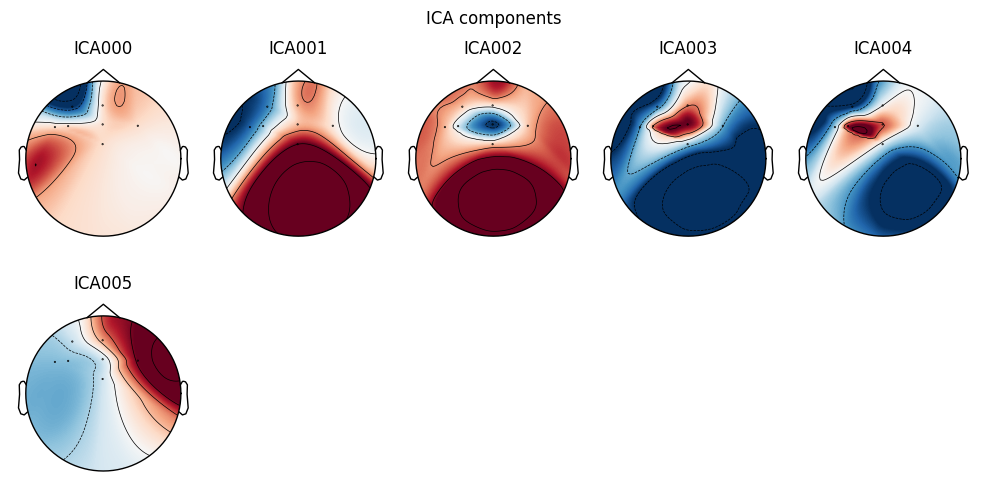

Creating RawArray with float64 data, n_channels=6, n_times=57546


    Range : 0 ... 57545 =      0.000 ...   230.180 secs


Ready.


Using matplotlib as 2D backend.


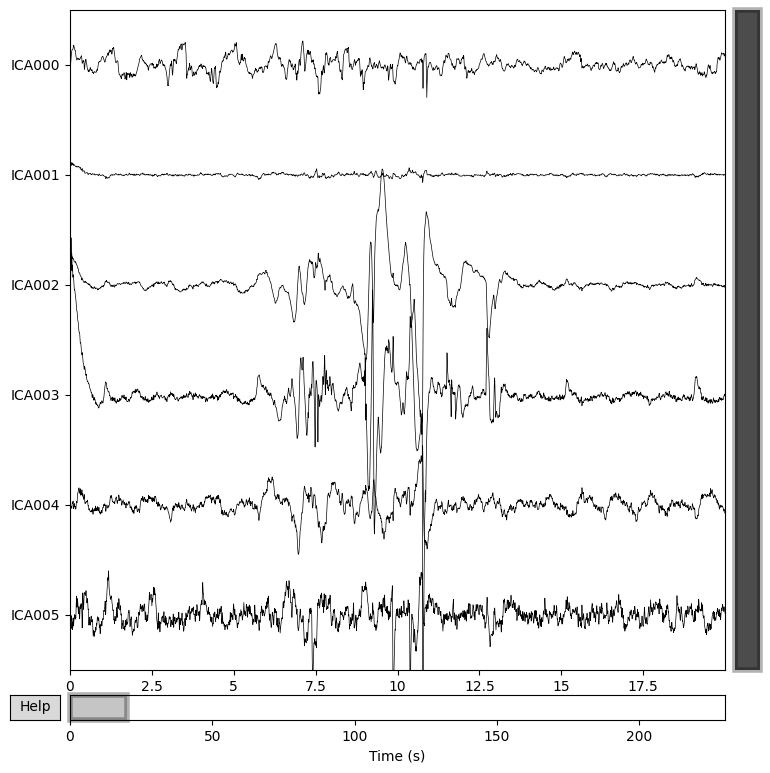

Applying ICA to Raw instance


    Transforming to ICA space (6 components)


    Zeroing out 4 ICA components


    Projecting back using 7 PCA components


In [10]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data

df = pd.DataFrame(eeg_raw.copy())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')
df.drop(['Timestamp', 'Ch12'], axis = 1, inplace = True)

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping --> make it less manual
ch_names = [
    "Fz",   # 1
    "FC3",   # 2
    "FC5",  # 3
    "F3",   # 4
    "FC4",   # 5
    "FCz",  # 6
    "Cz",  # 7
    #"F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
# 1–40 Hz is a good compromise for ICA + PSD
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
#raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming')
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99999,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

# Inspect components:
ica.plot_components()      # scalp maps
ica.plot_sources(raw)      # time series

# After inspecting, set the components you want to remove:
ica.exclude = [0,1,2,3]  # don't know how to do this
raw_clean = ica.apply(raw.copy())



In [11]:
# lifu_on_time_onset is an array of times in seconds
event_samples = trials

# Build MNE event array: shape (n_events, 3)
# Columns: [sample_index, 0, event_id]
events = np.column_stack([event_samples, 
                          np.zeros_like(event_samples, dtype=int), 
                          np.ones_like(event_samples, dtype=int)])
tmin = -0.2
tmax = 0.8

epochs = mne.Epochs(
    raw,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=(-0.2, 0),     # or (-2, 0) if you want baseline correction
    preload=True
)


Not setting metadata


100 matching events found


Applying baseline correction (mode: mean)


0 projection items activated


Using data from preloaded Raw for 100 events and 251 original time points ...


0 bad epochs dropped


In [12]:
erp = epochs.average()
erp

<Evoked | '1' (average, N=100), -0.2 – 0.8 s, baseline -0.2 – 0 s, 7 ch, ~29 KiB>

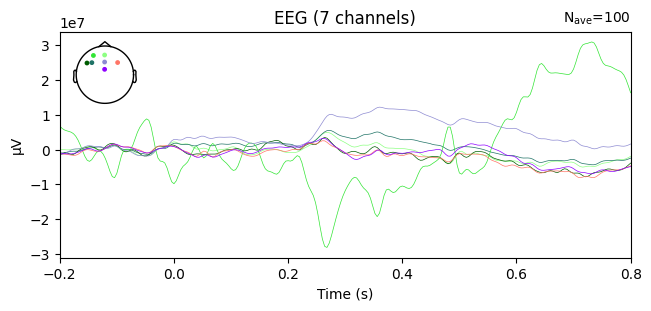

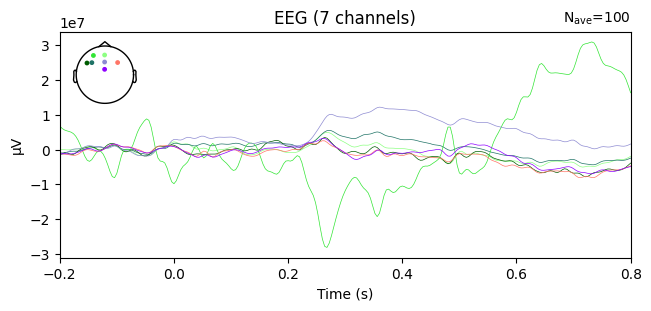

In [13]:
erp.plot()